<a href="https://colab.research.google.com/github/annhater/M1_STAGE/blob/main/2_notebooks/03_plot_ramachandran.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Plotting a Ramachandran map with `matplotlib`

In [ ]:
!pip install mdtraj

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 35.9 MB/s eta 0:00:00


In [ ]:
%matplotlib inline
import mdtraj as md

Lets load up the trajectory that we simulated in a previous example

In [ ]:
traj = md.load("ala2.h5")
atoms, bonds = traj.topology.to_dataframe()
atoms

,serial,name,element,resSeq,resName,chainID,segmentID,formal_charge
0,None,H1,H,1,ACE,0,,<NA>
1,None,CH3,C,1,ACE,0,,<NA>
2,None,H2,H,1,ACE,0,,<NA>
3,None,H3,H,1,ACE,0,,<NA>
4,None,C,C,1,ACE,0,,<NA>
5,None,O,O,1,ACE,0,,<NA>
6,None,N,N,2,ALA,0,,<NA>
7,None,H,H,2,ALA,0,,<NA>
8,None,CA,C,2,ALA,0,,<NA>
9,None,HA,H,2,ALA,0,,<NA>


Because alanine dipeptide is a little nonstandard in the sense that it's basically dominated by the ACE and NME capping residues, we need to find the indicies of the atoms involved in the phi and psi angles somewhat manually. For standard cases, see `compute_phi()` and `compute_psi()` for easier solutions that don't require you to manually find the indices of each dihedral angle.

In this case, we're just specifying the four atoms that together parameterize the phi and psi dihedral angles.

In [ ]:
psi_indices, phi_indices = [6, 8, 14, 16], [4, 6, 8, 14]
angles = md.compute_dihedrals(traj, [phi_indices, psi_indices])

In [ ]:
angles

array([[-1.1239667 ,  2.7346942 ],
       [-1.1615908 ,  2.4664226 ],
       [-1.7540604 ,  2.854215  ],
       [-2.4343033 ,  2.8321552 ],
       [-2.4964638 ,  2.7468665 ],
       [-1.1943909 ,  2.575996  ],
       [-2.7015128 ,  2.909936  ],
       [-1.9073789 ,  2.4053676 ],
       [-1.830295  ,  2.7732162 ],
       [-1.3592622 ,  2.622047  ],
       [-2.400468  ,  2.8990974 ],
       [-2.2040153 ,  2.8954358 ],
       [-1.0221933 ,  2.6574938 ],
       [-1.2256628 ,  2.6722739 ],
       [-2.5970278 ,  2.4548724 ],
       [-2.619608  , -3.0273917 ],
       [-2.617805  , -3.0887141 ],
       [-1.7312051 ,  2.5115042 ],
       [-2.7967026 ,  3.1051838 ],
       [-1.2913541 ,  0.9969263 ],
       [-1.7189113 ,  0.3766999 ],
       [-1.2591071 , -0.00962394],
       [-1.6617904 , -0.20992406],
       [-1.1883907 , -0.01445308],
       [-1.2226648 , -0.5530517 ],
       [-1.4288393 , -0.3274179 ],
       [-1.5690763 ,  0.46391642],
       [-1.3557873 ,  0.39400774],
       [-1.9155961 ,

In [ ]:
angles.reshape()

(100, 2)

Lets plot our dihedral angles in a scatter plot using matplotlib. What conformational states of Alanine dipeptide did we sample?

(-3.141592653589793, 3.141592653589793)

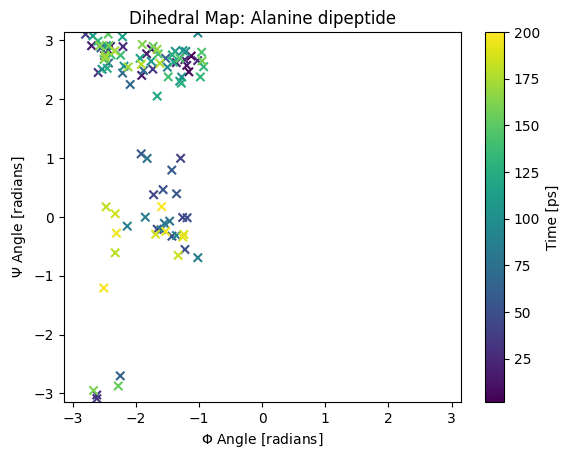

In [ ]:
from math import pi
import matplotlib.pyplot as plt

 = figure()
title("Dihedral Map: Alanine dipeptide")
scatter(angles[:, 0], angles[:, 1], marker="x", c=traj.time)
cbar = colorbar()
cbar.set_label("Time [ps]")
xlabel(r"$\Phi$ Angle [radians]")
xlim(-pi, pi)
ylabel(r"$\Psi$ Angle [radians]")
ylim(-pi, pi)

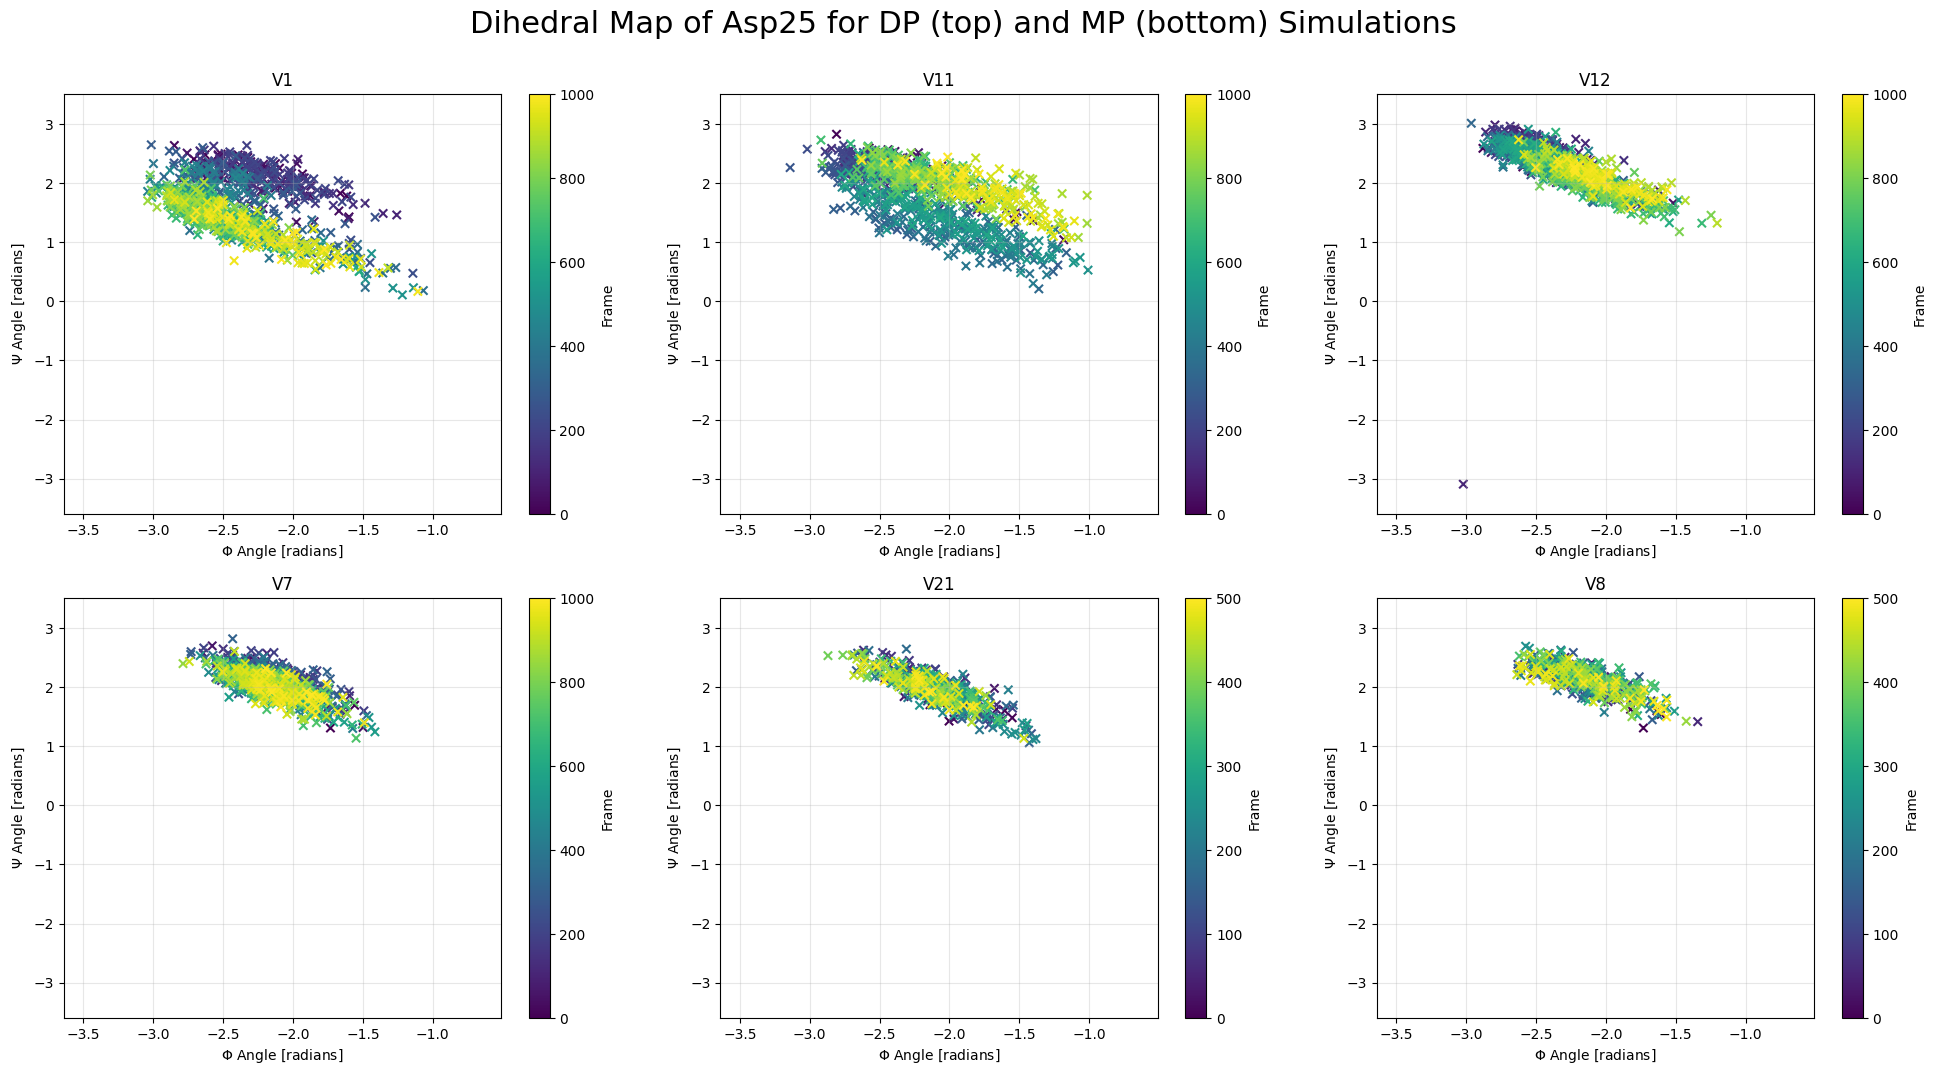

In [ ]:
import os
import pandas as pd
import numpy as np
import  matplotlib.pyplot as plt
import mdtraj as md
#import MDAnalysis as mda
from math import pi


#SETUP
rootdir = '/content/drive/MyDrive/M1_STAGE/Data/simulations_1HSI/'
os.chdir(rootdir)


#FUNCTIONS

#def

#MAIN

# 1. Fetch all simulation files
simulation_files = []

for subdir, dirs, files in os.walk(rootdir):
    pdb_files_pathnames = [f for f in files if f.endswith("_renum.pdb")]
    xtc_files_pathnames = [f for f in files if f.endswith(".xtc")]

    for pdb_name in pdb_files_pathnames:
        sim_name_match = pdb_name.replace("_renum.pdb", "").replace("_all", "")

        found_xtc = None
        for xtc_name in xtc_files_pathnames:
            if sim_name_match in xtc_name  and xtc_name.endswith('.xtc'):
                found_xtc = xtc_name
                break
        if found_xtc:
            pdb_path = os.path.join(subdir, pdb_name)
            xtc_path = os.path.join(subdir, found_xtc)
            simulation_files.append((pdb_path, xtc_path))

all_sim_asp25_phi = []
all_sim_asp25_psi = []
all_angles = []
sim_names = []
all_n_frames = [] # To store n_frame for each trajectory
min_x = []
max_x = []
min_y = []
max_y = []
# Load trajectories with MDTraj
for pdb, xtc in simulation_files:
    sim_name = os.path.basename(os.path.dirname(pdb))
    sim_names.append(sim_name)
    topology = md.load(pdb).topology
    traj = md.load(xtc,top=topology)
    all_n_frames.append(traj.n_frames) # Store n_frames for current trajectory
    #Select Asp25
    #top_asp25 = topology.select('resid 24 and resname ASP')
    #traj_asp25 = md.load(xtc, top=top_asp25)
    #print(asp25)
    phi_indx,phi_vals = md.compute_phi(traj)
    psi_indx,psi_vals = md.compute_psi(traj)

    asp_indx = 24

    asp25_phi = phi_vals[:, asp_indx - 1]
    min_asp25_phi, max_asp25_phi = min(asp25_phi),max(asp25_phi)
    min_x.append(min_asp25_phi)
    max_x.append(max_asp25_phi)
    asp25_psi = psi_vals[:, asp_indx - 1]
    min_asp25_psi, max_asp25_psi = min(asp25_psi),max(asp25_psi)
    min_y.append(min_asp25_psi)
    max_y.append(max_asp25_psi)
    asp25_angles = [list(x) for x in zip(asp25_phi, asp25_psi)]
    asp25_angles = np.array(asp25_angles)
    all_angles.append(asp25_angles)
#Prep for plot
num_simulations = len(sim_names) # Use the actual number of simulations found
num_cols_plot = min(num_simulations, 3)
num_rows_plot = (num_simulations + num_cols_plot - 1) // num_cols_plot

fig, axes = plt.subplots(num_rows_plot, num_cols_plot, figsize=(num_cols_plot * 8, num_rows_plot * 6), squeeze=False)
axes = axes.flatten()
plot_idx = 0
fig.suptitle("Dihedral Map of Asp25 for DP (top) and MP (bottom) Simulations", fontsize=22, y=0.95)

lim_x0, lim_x1 = min(min_x), max(max_x)
lim_y0, lim_y1 = min(min_y), max(max_y)

#Plot
for i, (current_sim_name, angles_data, n_frames) in enumerate(zip(sim_names, all_angles, all_n_frames)):
    ax = axes[i] # Assign the correct Axes object for plotting
    # Plot scatter points and store the PathCollection object for the colorbar
    sc = ax.scatter(angles_data[:,0], angles_data[:,1], marker="x", c=np.arange(n_frames))
    ax.set_title(f"{current_sim_name}")
    cbar = fig.colorbar(sc, ax=ax) # Create colorbar using the PathCollection and attach to current axes
    cbar.set_label("Frame")
    ax.set_xlabel(r"$\Phi$ Angle [radians]")
    ax.set_ylabel(r"$\Psi$ Angle [radians]")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(lim_x0-0.5, lim_x1+0.5)
    ax.set_ylim(lim_y0-0.5, lim_y1+0.5)
    plot_idx += 1

plt.show()

# Define the full path for saving the figure
#figure_filepath = "/home/sdv/m1isdd/aperova/Documents/M1_STAGE/Manips/Figures/angles.png"
# Create the directory if it doesn't exist
#os.makedirs(os.path.dirname(figure_filepath), exist_ok=True)
#fig.savefig(figure_filepath, bbox_inches='tight', dpi=300)

# Hide any unused subplots
for j in range(plot_idx, len(axes)):
    fig.delaxes(axes[j])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
